# CDS-aware exploration of the manipulations

**Premise:** the SpliceAI test datafile only stores transcript boundaries (`TX_START`/`TX_END`) and splice junctions. So our current `nt_shuffle` / `codon_shuffle` / `remove1` / `remove2` operate on the **whole concatenated exonic content** — which mixes 5′ UTR, CDS, and 3′ UTR letters. That's likely fine for sequence-level signals (composition, codons), but if we believe the model picks up **coding-frame** information specifically, we should be shuffling *only inside the CDS* and leaving UTRs intact.

This notebook walks through:

1. Loading **GENCODE v46 lift37 (basic, GRCh37)** — chr1 subset already extracted to `data/gencode/chr1.gff3`.
2. Picking the GENCODE transcript whose **splice junctions actually match** our datafile (not just the Ensembl_canonical one — sometimes those differ).
3. Mapping CDS to **sense-strand positions** that line up with our datafile.
4. **Visualizing** UTR / CDS / intron structure across the original and current manipulations.
5. **Quantifying the flaw**: how much of each "shuffled exonic content" is actually UTR rather than CDS?
6. **Prototyping a CDS-only nt-shuffle** — in-notebook only, no changes to `manipulate_exons.py` yet.

> Source: GENCODE v46 lifted to GRCh37. Download URL:
> https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_46/GRCh37_mapping/gencode.v46lift37.basic.annotation.gff3.gz
>
> If you want to match the SpliceAI paper exactly, swap in `release_24/GRCh37_mapping/gencode.v24lift37.basic.annotation.gff3.gz`. Canonical-transcript CDS coords are nearly identical across releases.

In [1]:
from __future__ import annotations
import json, sys
from collections import Counter, defaultdict
from pathlib import Path

import h5py
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display

REPO_ROOT = Path('..').resolve()
sys.path.insert(0, str(REPO_ROOT / 'experiments'))
from manipulate_exons import build_exon_spans, gene_to_sense, get_gene_record, reverse_complement

GFF_CHR1 = REPO_ROOT / 'data' / 'gencode' / 'chr1.gff3'
DATAFILE = REPO_ROOT / 'datafile_test_0.h5'
MANIPULATED = {
    'nt_shuffle':     REPO_ROOT / 'datafile_test_nt_shuffle.h5',
    'codon_shuffle':  REPO_ROOT / 'datafile_test_codon_shuffle.h5',
    'remove1':        REPO_ROOT / 'datafile_test_remove1.h5',
    'remove2':        REPO_ROOT / 'datafile_test_remove2.h5',
}

assert GFF_CHR1.exists(), f'Run the download first: missing {GFF_CHR1}'
print(f'GFF: {GFF_CHR1} ({GFF_CHR1.stat().st_size / 1e6:.1f} MB)')
print(f'Datafile: {DATAFILE} ({DATAFILE.stat().st_size / 1e9:.1f} GB)')

GFF: /mnt/lareaulab/mparsa/splicing/data/gencode/chr1.gff3 (110.5 MB)
Datafile: /mnt/lareaulab/mparsa/splicing/datafile_test_0.h5 (2.5 GB)


## Parse the GFF3 (chr1 only)

We don't depend on `gffutils` (not installed) and just walk the file linearly. We collect, per transcript:

* `tx_id`, `gene_name`, `strand`, `tx_start`, `tx_end` (1-based, inclusive — we'll convert)
* list of `exon` records (genomic 1-based intervals)
* list of `CDS` records (genomic 1-based intervals)
* `tags` (we use these for diagnostic purposes)

In [2]:
def parse_attrs(s: str) -> dict:
    out = {}
    for kv in s.strip().split(';'):
        if not kv.strip():
            continue
        if '=' in kv:
            k, v = kv.split('=', 1)
            out[k.strip()] = v.strip()
    return out

transcripts: dict = {}
by_gene_name: dict = defaultdict(list)

with open(GFF_CHR1) as f:
    for line in f:
        if line.startswith('#') or not line.strip():
            continue
        cols = line.rstrip('\n').split('\t')
        if len(cols) < 9:
            continue
        chrom, src, feat, start, end, _, strand, _, attrs = cols
        if feat == 'transcript':
            a = parse_attrs(attrs)
            tx_id = a.get('ID') or a['transcript_id']
            tags = a.get('tag', '').split(',')
            rec = dict(
                tx_id=tx_id,
                gene_id=a.get('gene_id', ''),
                gene_name=a.get('gene_name', ''),
                tx_type=a.get('transcript_type', ''),
                strand=strand,
                tx_start=int(start), tx_end=int(end),
                tags=set(t.strip() for t in tags if t.strip()),
                exons=[],
                cds=[],
            )
            transcripts[tx_id] = rec
            by_gene_name[rec['gene_name']].append(rec)
        elif feat == 'exon':
            a = parse_attrs(attrs)
            tx_id = a.get('Parent', '')
            if tx_id in transcripts:
                transcripts[tx_id]['exons'].append((int(start), int(end)))
        elif feat == 'CDS':
            a = parse_attrs(attrs)
            tx_id = a.get('Parent', '')
            if tx_id in transcripts:
                transcripts[tx_id]['cds'].append((int(start), int(end)))

for r in transcripts.values():
    r['exons'].sort()
    r['cds'].sort()

print(f'parsed {len(transcripts):,} transcripts across {len(by_gene_name):,} gene names on chr1')
print('  protein-coding transcripts:', sum(1 for r in transcripts.values() if r['tx_type'] == 'protein_coding'))

parsed 11,077 transcripts across 5,643 gene names on chr1
  protein-coding transcripts: 6405


## Pick the matching GENCODE transcript

Naively picking `Ensembl_canonical` doesn't always work — the SpliceAI test set was built with a specific transcript per gene that might not be GENCODE's canonical. So we **search GENCODE for the transcript whose splice junctions match the datafile's** `JN_START` / `JN_END` exactly. That guarantees the CDS we look up is the same isoform the datafile is built around.

In [3]:
GENE_NAME = 'AZIN2'   # try also 'LIN9' (- strand), 'PRUNE1', 'NCKAP5', 'C1orf21'

def find_gene_index(datafile_path: Path, name: str) -> int:
    with h5py.File(datafile_path, 'r') as f:
        for i, n in enumerate(f['NAME'][:]):
            if n.decode() == name:
                return i
    raise KeyError(name)

GENE_IDX = find_gene_index(DATAFILE, GENE_NAME)
with h5py.File(DATAFILE, 'r') as f:
    df_rec = get_gene_record(f, GENE_IDX)
print(f"Datafile: idx={GENE_IDX}  strand={df_rec['strand']}  "
      f"TX=[{df_rec['tx_start']:,}, {df_rec['tx_end']:,})  gene_len={df_rec['gene_len']:,}  #junctions={len(df_rec['jn_start'])}")

# IMPORTANT — coordinate convention. The SpliceAI datafile and GENCODE V46-lift37
# disagree by exactly 1 bp on exon-boundary indexing for many genes (likely because
# SpliceAI used GENCODE V24, or used a slightly different end-of-exon convention).
# Empirically, GENCODE's `exon_end_1based - 1` corresponds to datafile's `donor_pos`
# in some genes and to `donor_pos - 1` in others. We therefore allow a ±1 tolerance
# when matching junctions.
TOLERANCE = 1

def transcript_junctions_genomic(tx_rec: dict) -> tuple[set[int], set[int]]:
    exons = sorted(tx_rec['exons'])  # 1-based inclusive
    donors = {e - 1 for _, e in exons[:-1]}        # 0-based last base of upstream exon
    acceptors = {s - 1 for s, _ in exons[1:]}      # 0-based first base of downstream exon
    return donors, acceptors

def fuzzy_set_match(a: set[int], b: set[int], tol: int = TOLERANCE) -> int:
    if tol == 0:
        return len(a & b)
    sb = sorted(b)
    matches = 0
    for x in a:
        # binary-search-ish check
        for d in range(-tol, tol + 1):
            if (x + d) in b:
                matches += 1
                break
    return matches

def transcript_match_score(tx_rec: dict, df_rec: dict) -> tuple[int, int]:
    df_donors = set(df_rec['jn_start']); df_acceptors = set(df_rec['jn_end'])
    tx_donors, tx_acceptors = transcript_junctions_genomic(tx_rec)
    return (fuzzy_set_match(df_donors, tx_donors) + fuzzy_set_match(df_acceptors, tx_acceptors),
            len(df_donors) + len(df_acceptors))

def pick_matching_transcript(gene_name: str, df_rec: dict) -> tuple:
    cands = list(by_gene_name.get(gene_name, []))
    if not cands:
        return None, (0, 0)
    pc = [r for r in cands if r['tx_type'] == 'protein_coding']
    if pc:
        cands = pc
    scored = [(transcript_match_score(r, df_rec), r) for r in cands]
    scored.sort(key=lambda x: (x[0][0], x[0][1]), reverse=True)
    return scored[0][1], scored[0][0]

# Determine the global offset between datafile and GENCODE for the chosen transcript.
def detect_offset(tx_rec: dict, df_rec: dict, max_off: int = 2) -> int:
    df_d = set(df_rec['jn_start']); df_a = set(df_rec['jn_end'])
    g_d, g_a = transcript_junctions_genomic(tx_rec)
    best_off, best_match = 0, -1
    for off in range(-max_off, max_off + 1):
        m = (len({x + off for x in g_d} & df_d) + len({x + off for x in g_a} & df_a))
        if m > best_match:
            best_off = off; best_match = m
    return best_off

tx, (n_match, n_total) = pick_matching_transcript(GENE_NAME, df_rec)
if tx is None:
    raise ValueError(f'No transcript found for {GENE_NAME}')
GENCODE_OFFSET = detect_offset(tx, df_rec)
print(f"GENCODE pick: {tx['tx_id']}  ({tx['tx_type']})  strand={tx['strand']}  "
      f"tx=[{tx['tx_start']:,}, {tx['tx_end']:,}]  exons={len(tx['exons'])}  cds_segments={len(tx['cds'])}")
print(f"  fuzzy junction match (±{TOLERANCE}): {n_match}/{n_total}  ({100*n_match/max(n_total,1):.0f}%)")
print(f"  detected genomic offset (apply this to GENCODE coords to align with datafile): {GENCODE_OFFSET:+d}")
print(f"  tags: {sorted(tx['tags'])}")

Datafile: idx=0  strand=+  TX=[33,546,714, 33,585,995)  gene_len=39,281  #junctions=11
GENCODE pick: ENST00000294517.11  (protein_coding)  strand=+  tx=[33,546,754, 33,589,093]  exons=12  cds_segments=9
  fuzzy junction match (±1): 22/22  (100%)
  detected genomic offset (apply this to GENCODE coords to align with datafile): +1
  tags: ['CCDS', 'Ensembl_canonical', 'GENCODE_Primary', 'MANE_Select', 'alternative_5_UTR', 'appris_principal_1', 'basic']


## Map UTRs / CDS / introns onto the sense strand

Build a per-position annotation array of length `sense_len` with values `5UTR`, `CDS`, `3UTR`, `intron`, or `flank`. For `−` strand we convert genomic coords using the same formula as `gene_to_sense` (`sense_pos = tx_end − g`).

In [4]:
def genomic_to_sense_positions(rec: dict, gff_intervals: list[tuple[int, int]],
                                gencode_offset: int = 0) -> list[tuple[int, int]]:
    """Convert 1-based GFF intervals to half-open sense-strand intervals.

    ``gencode_offset`` is added to every genomic coordinate before converting,
    to compensate for the 1-bp disagreement between the SpliceAI datafile and
    GENCODE V46-lift37."""
    out = []
    for s_1, e_1 in gff_intervals:
        g_lo, g_hi = s_1 - 1 + gencode_offset, e_1 + gencode_offset
        if rec['strand'] == '+':
            s_sense = g_lo - rec['tx_start']
            e_sense = g_hi - rec['tx_start']
        else:
            s_sense = rec['tx_end'] - g_hi + 1
            e_sense = rec['tx_end'] - g_lo + 1
        out.append((max(s_sense, 0), min(e_sense, rec['sense_len'])))
    return [iv for iv in sorted(out) if iv[1] > iv[0]]

exon_sense = genomic_to_sense_positions(df_rec, tx['exons'], GENCODE_OFFSET)
cds_sense = genomic_to_sense_positions(df_rec, tx['cds'], GENCODE_OFFSET)

# Annotate every sense position. Default to 'flank'; gene proper starts as 'intron';
# exonic positions overwrite to UTR; CDS overwrites again. Then split UTR into 5'/3'.
ann = np.full(df_rec['sense_len'], 'flank', dtype=object)
ann[df_rec['gene_offset']:df_rec['gene_offset'] + df_rec['gene_len']] = 'intron'
for s, e in exon_sense:
    ann[s:e] = '5UTR'
for s, e in cds_sense:
    ann[s:e] = 'CDS'
if cds_sense:
    cds_max = max(e for _, e in cds_sense)
    for i in range(len(ann)):
        if ann[i] == '5UTR' and i >= cds_max:
            ann[i] = '3UTR'

print('Position annotation counts:')
for k, v in sorted(Counter(ann).items(), key=lambda kv: -kv[1]):
    print(f'  {k:7s}  {v:>8,} bp')

# Sanity: every junction should fall on an exon (annotation 5UTR/CDS/3UTR)
sense, donors, acceptors = gene_to_sense(df_rec)
n_jct_off_exon = sum(1 for p in donors + acceptors if ann[p] not in ('5UTR', 'CDS', '3UTR'))
print(f'Junctions falling outside annotated exons: {n_jct_off_exon} (should be 0 if isoform matched)')

Position annotation counts:
  intron     37,140 bp
  CDS         1,383 bp
  5UTR          547 bp
  3UTR          212 bp
Junctions falling outside annotated exons: 0 (should be 0 if isoform matched)


## Visualize: gene structure with UTR / CDS / intron colours

Colours: 5′ UTR = pale blue, CDS = navy, 3′ UTR = pale orange, intron = grey line. Donor `▼` and acceptor `▲` markers on the splice sites.

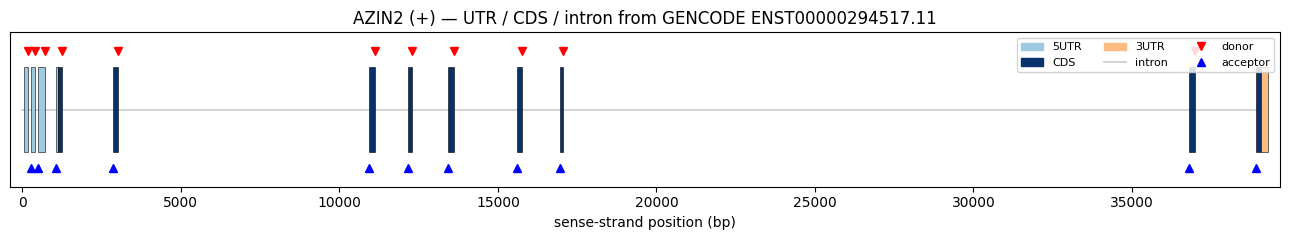

In [5]:
REGION_COLOURS = {'5UTR': '#9ecae1', 'CDS': '#08306b', '3UTR': '#fdbb84', 'intron': 'lightgrey', 'flank': 'white'}

def plot_annotated(ann: np.ndarray, donors: list[int], acceptors: list[int],
                   gene_offset: int, gene_len: int, title: str = '', figsize=(13, 2.5)):
    fig, ax = plt.subplots(figsize=figsize)
    runs = []
    cur = None
    for i in range(gene_offset, gene_offset + gene_len):
        if cur is None or ann[i] != cur[0]:
            if cur is not None:
                runs.append((cur[1], i, cur[0]))
            cur = (ann[i], i)
    if cur is not None:
        runs.append((cur[1], gene_offset + gene_len, cur[0]))
    for s, e, label in runs:
        if label == 'intron':
            ax.plot([s - gene_offset, e - gene_offset], [0.5, 0.5], color=REGION_COLOURS['intron'], lw=1.4, zorder=1)
        else:
            ax.add_patch(mpatches.Rectangle((s - gene_offset, 0.2), e - s, 0.6,
                                            facecolor=REGION_COLOURS[label], edgecolor='black', lw=0.4, zorder=2))
    for d in donors:
        ax.plot(d - gene_offset, 0.92, marker='v', markersize=6, color='red', zorder=3)
    for a in acceptors:
        ax.plot(a - gene_offset, 0.08, marker='^', markersize=6, color='blue', zorder=3)
    ax.set_xlim(-gene_len * 0.01, gene_len * 1.01)
    ax.set_ylim(-0.05, 1.05)
    ax.set_yticks([])
    ax.set_xlabel('sense-strand position (bp)')
    ax.set_title(title)
    handles = [mpatches.Patch(color=REGION_COLOURS[k], label=k) for k in ('5UTR', 'CDS', '3UTR')]
    handles += [plt.Line2D([], [], color=REGION_COLOURS['intron'], lw=1.4, label='intron'),
                plt.Line2D([], [], marker='v', color='red', lw=0, label='donor'),
                plt.Line2D([], [], marker='^', color='blue', lw=0, label='acceptor')]
    ax.legend(handles=handles, fontsize=8, loc='upper right', ncol=3, framealpha=0.85)
    plt.tight_layout()
    return fig

fig = plot_annotated(ann, donors, acceptors,
                     df_rec['gene_offset'], df_rec['gene_len'],
                     title=f"{GENE_NAME} ({df_rec['strand']}) — UTR / CDS / intron from GENCODE {tx['tx_id']}")
plt.show()

## Quantify the flaw: how much UTR is in our "shuffled exonic content"?

Our current manipulations concatenate **all exonic positions** and shuffle. Let's measure how much of that pool is actually UTR vs CDS for this gene — and across the whole test set.

In [6]:
exon_spans = build_exon_spans(donors, acceptors,
                              df_rec['gene_offset'],
                              df_rec['gene_offset'] + df_rec['gene_len'])
exonic_positions = [p for s, e in exon_spans for p in range(s, e)]
labels = Counter(ann[p] for p in exonic_positions)
total = sum(labels.values())
print(f"For {GENE_NAME}: of the {total:,} exonic positions we currently shuffle:")
for k, v in sorted(labels.items(), key=lambda kv: -kv[1]):
    print(f'  {k:7s}  {v:>7,}  ({100 * v / total:5.1f}%)')

For AZIN2: of the 2,181 exonic positions we currently shuffle:
  CDS        1,383  ( 63.4%)
  5UTR         547  ( 25.1%)
  3UTR         211  (  9.7%)
  intron        40  (  1.8%)


In [7]:
# Whole-test-set sweep. For each gene we (1) find the best-matching transcript with ±1 fuzzy
# matching, (2) detect the per-gene offset, (3) compute CDS coverage of exonic content. Genes
# with too few matching junctions are skipped.
with h5py.File(DATAFILE, 'r') as f:
    n = f['NAME'].shape[0]
    test_names = [f['NAME'][i].decode() for i in range(n)]

stats = {'matched': 0, 'no_pc_tx': 0, 'no_cds': 0, 'low_match': 0}
per_gene = []
for i, name in enumerate(test_names):
    pc = [r for r in by_gene_name.get(name, []) if r['tx_type'] == 'protein_coding']
    if not pc:
        stats['no_pc_tx'] += 1; continue
    with h5py.File(DATAFILE, 'r') as f:
        rec = get_gene_record(f, i)
    cand, (m, t) = pick_matching_transcript(name, rec)
    if cand is None or not cand['cds']:
        stats['no_cds'] += 1; continue
    if t > 0 and m / t < 0.5:
        stats['low_match'] += 1; continue
    off = detect_offset(cand, rec)
    s_sense, d_, a_ = gene_to_sense(rec)
    e_spans = build_exon_spans(d_, a_, rec['gene_offset'], rec['gene_offset'] + rec['gene_len'])
    cds_in_sense = genomic_to_sense_positions(rec, cand['cds'], off)
    cds_mask = np.zeros(rec['sense_len'], dtype=bool)
    for s, e in cds_in_sense:
        cds_mask[s:e] = True
    exonic_count = sum(e - s for s, e in e_spans)
    cds_count = sum(int(cds_mask[s:e].sum()) for s, e in e_spans)
    per_gene.append((name, exonic_count, cds_count, exonic_count - cds_count))
    stats['matched'] += 1

print('test-set match stats:', stats)
exonic_total = sum(x[1] for x in per_gene)
cds_total = sum(x[2] for x in per_gene)
utr_total = sum(x[3] for x in per_gene)
if exonic_total > 0:
    print(f'\nAcross {len(per_gene):,} matched genes:')
    print(f'  total exonic content:  {exonic_total:,} bp')
    print(f'  of which CDS:          {cds_total:,} bp  ({100*cds_total/exonic_total:.1f}%)')
    print(f'  of which UTR:          {utr_total:,} bp  ({100*utr_total/exonic_total:.1f}%)')
else:
    print('\nNo genes matched — check the GFF source / matching logic.')

test-set match stats: {'matched': 528, 'no_pc_tx': 1124, 'no_cds': 0, 'low_match': 0}

Across 528 matched genes:
  total exonic content:  1,534,147 bp
  of which CDS:          749,463 bp  (48.9%)
  of which UTR:          784,684 bp  (51.1%)


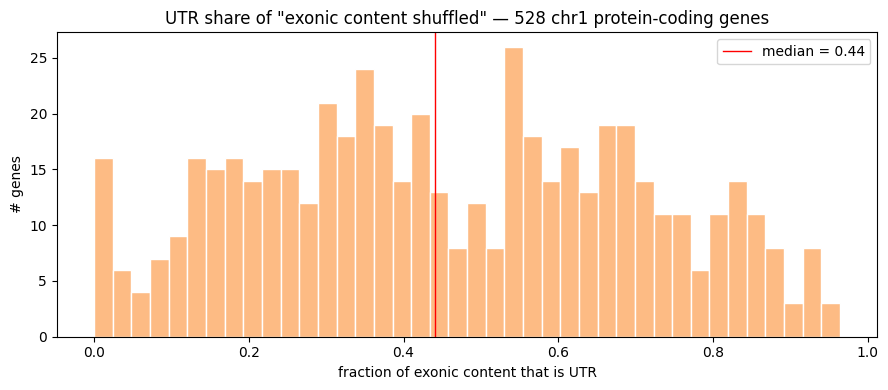

In [8]:
utr_frac = np.array([x[3] / x[1] for x in per_gene if x[1] > 0])
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(utr_frac, bins=40, color='#fdbb84', edgecolor='white')
ax.set_xlabel('fraction of exonic content that is UTR')
ax.set_ylabel('# genes')
ax.set_title(f'UTR share of "exonic content shuffled" — {len(utr_frac):,} chr1 protein-coding genes')
ax.axvline(np.median(utr_frac), color='red', lw=1, label=f'median = {np.median(utr_frac):.2f}')
ax.legend()
plt.tight_layout()
plt.show()

## Side-by-side text: where do shuffled letters end up?

Render the first 240 bp of the concatenated exonic sequence (= what we feed the shuffles), with each letter's **background colour** indicating whether it originated from 5′ UTR / CDS / 3′ UTR. Compare original vs `nt_shuffle` — letters now sit at a position that may have a different region annotation than where they came from.

In [9]:
def concat_exonic_with_origin(ann: np.ndarray, sense: str, exon_spans: list[tuple[int,int]]):
    chars, origins = [], []
    for s, e in exon_spans:
        for p in range(s, e):
            chars.append(sense[p])
            origins.append(ann[p])
    return ''.join(chars), origins

orig_concat, orig_origins = concat_exonic_with_origin(ann, sense, exon_spans)

# Recreate the nt_shuffle on the SAME pool with the SAME seed used by the main script,
# so the rendering matches what we actually wrote to disk.
rng = np.random.default_rng(42 + GENE_IDX)   # base seed for nt_shuffle is 42
perm = rng.permutation(len(orig_concat))
shuf_concat = ''.join(orig_concat[p] for p in perm)
shuf_origins = [orig_origins[p] for p in perm]   # origin label TRAVELS WITH the letter

with h5py.File(MANIPULATED['nt_shuffle'], 'r') as f:
    nt_rec = get_gene_record(f, GENE_IDX)
nt_sense, nt_d, nt_a = gene_to_sense(nt_rec)
nt_exon_spans = build_exon_spans(nt_d, nt_a, nt_rec['gene_offset'], nt_rec['gene_offset'] + nt_rec['gene_len'])
nt_concat = ''.join(nt_sense[s:e] for s, e in nt_exon_spans)
print(f'In-notebook reconstruction matches on-disk nt_shuffle: {nt_concat == shuf_concat}')

In-notebook reconstruction matches on-disk nt_shuffle: True


In [10]:
ORIGIN_BG = {'5UTR': '#cfe2f3', 'CDS': '#08306b', '3UTR': '#fdbb84'}
ORIGIN_FG = {'5UTR': 'black',   'CDS': 'white',   '3UTR': 'black'}

def render_origin_destination(seq: str, origins: list, dest_origins: list, header: str,
                              max_chars: int = 1500) -> str:
    seq = seq[:max_chars]; origins = origins[:max_chars]; dest_origins = dest_origins[:max_chars]
    top, bot = [], []
    for ch, o, d in zip(seq, origins, dest_origins):
        bg, fg = ORIGIN_BG.get(o, '#bbb'), ORIGIN_FG.get(o, 'black')
        top.append(f'<span style="background:{bg};color:{fg};padding:0 1px">{ch}</span>')
        d_bg = ORIGIN_BG.get(d, '#bbb')
        bot.append(f'<span style="background:{d_bg};color:{d_bg};padding:0 1px">·</span>')
    return (f'<div><b>{header}</b><br>'
            f'<span style="font-family:monospace;font-size:11px">{"".join(top)}</span><br>'
            f'<span style="font-family:monospace;font-size:11px">{"".join(bot)}</span></div><br>')

html = '<div style="font-family:monospace">'
html += f'<b>{GENE_NAME}: first 1500 bp of concatenated exonic content</b><br>'
html += ('Top strip = letter (background = where the letter ORIGINATED). '
         'Bottom strip = position-annotation (where the letter SITS NOW).<br>'
         'Legend: <span style="background:#cfe2f3;padding:0 4px">5′ UTR</span> '
         '<span style="background:#08306b;color:white;padding:0 4px">CDS</span> '
         '<span style="background:#fdbb84;padding:0 4px">3′ UTR</span><br><br>')
html += render_origin_destination(orig_concat, orig_origins, orig_origins, 'original concat (origin = destination)')
html += render_origin_destination(shuf_concat, shuf_origins, orig_origins, 'nt_shuffle (top = letter origin, bottom = destination at this position)')
html += '</div>'
display(HTML(html))

Where the **top** band differs from the **bottom** band, the letter has crossed a UTR↔CDS boundary — that's the leakage we don't want when testing CDS-frame signals.

In [11]:
n_mismatch = sum(1 for o, d in zip(shuf_origins, orig_origins) if o != d)
print(f'{n_mismatch:,} of {len(orig_concat):,} positions ({100*n_mismatch/len(orig_concat):.1f}%) crossed a UTR/CDS boundary in nt_shuffle for {GENE_NAME}.')

1,182 of 2,181 positions (54.2%) crossed a UTR/CDS boundary in nt_shuffle for AZIN2.


## Prototype: CDS-only nucleotide shuffle

Here's what a *correct* `nt_shuffle` should do once we trust the GENCODE CDS: take only the **CDS positions** within exons, permute them, write back, and leave UTR exonic positions untouched. This is in-notebook only — `experiments/manipulate_exons.py` is unchanged.

The same pattern would apply to `codon_shuffle` (codons in true translation frame from the start codon) and to `remove1` / `remove2` (delete only inside CDS).

In [12]:
def cds_only_nt_shuffle(rec: dict, ann: np.ndarray, seed: int) -> tuple[str, np.ndarray]:
    sense, d, a = gene_to_sense(rec)
    exon_spans = build_exon_spans(d, a, rec['gene_offset'], rec['gene_offset'] + rec['gene_len'])
    cds_positions = [p for s, e in exon_spans for p in range(s, e) if ann[p] == 'CDS']
    rng = np.random.default_rng(seed)
    pool = [sense[p] for p in cds_positions]
    perm = rng.permutation(len(pool))
    new_chars = list(sense)
    for src_idx, dst_pos in zip(perm, cds_positions):
        new_chars[dst_pos] = pool[src_idx]
    mask = np.zeros(len(sense), dtype=bool)
    for p in cds_positions:
        mask[p] = True
    return ''.join(new_chars), mask

new_sense, cds_mask = cds_only_nt_shuffle(df_rec, ann, seed=42 + GENE_IDX)
n_cds = int(cds_mask.sum())
n_diff_cds = sum(1 for i in range(len(sense)) if cds_mask[i] and sense[i] != new_sense[i])
n_diff_total = sum(1 for i in range(len(sense)) if sense[i] != new_sense[i])
print(f'CDS positions: {n_cds:,}')
print(f'  changed by CDS-only shuffle: {n_diff_cds:,} (UTR letters changed: {n_diff_total - n_diff_cds} — should be 0)')

cds_orig = [sense[p] for p in range(len(sense)) if cds_mask[p]]
cds_new = [new_sense[p] for p in range(len(sense)) if cds_mask[p]]
print(f'CDS composition preserved: {Counter(cds_orig) == Counter(cds_new)}')

CDS positions: 1,383
  changed by CDS-only shuffle: 1,017 (UTR letters changed: 0 — should be 0)
CDS composition preserved: True


In [18]:
concat_new = ''.join(new_sense[s:e] for s, e in exon_spans)
html = '<div style="font-family:monospace">'
html += f'<b>{GENE_NAME}: first 1500 bp — original / CDS-only shuffle / current nt_shuffle</b><br>'
html += ('Background colour shows the position annotation (where the letter sits in the concat). '
         'CDS-only shuffle leaves <span style="background:#cfe2f3;padding:0 4px">5′ UTR</span> and '
         '<span style="background:#fdbb84;padding:0 4px">3′ UTR</span> bytes untouched and only permutes within '
         '<span style="background:#08306b;color:white;padding:0 4px">CDS</span>.<br><br>')
for label, seqv in [('original         ', orig_concat),
                    ('CDS-only shuffle ', concat_new),
                    ('current nt_shuffle', shuf_concat)]:
    snippet = seqv[:]
    spans = []
    for i, ch in enumerate(snippet):
        bg = ORIGIN_BG.get(orig_origins[i], '#bbb')
        fg = ORIGIN_FG.get(orig_origins[i], 'black')
        spans.append(f'<span style="background:{bg};color:{fg};padding:0 1px">{ch}</span>')
    html += f'<b>{label}</b>  <span style="font-size:11px">{"".join(spans)}</span><br><br>'
html += '</div>'
display(HTML(html))

## Where to go next

If we agree CDS-aware manipulations are the right experiment:

1. **Cache CDS coords for every test gene** — write a small JSON keyed by datafile gene index, listing the CDS intervals in sense coords. (Lets us avoid re-parsing the GFF on every run, and gives the main script a clean dependency.)
2. **Update `manipulate_exons.py`** to accept an optional CDS-mask source. Each manipulation mode picks its working pool from CDS positions only when the mask is provided.
3. **Decide what to do with genes lacking a protein-coding match** in GENCODE (lncRNAs, pseudogenes, isoform mismatches). Options: skip, fall back to whole-exon shuffling, or fall back and tag.
4. **Re-generate the four manipulated datasets** with CDS-aware shuffling, and rerun the SpliceMamba / SpliceAI evaluations to see how the AUPRC drop changes once UTRs are protected.